In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv('DATASET/coffee_shop_revenue.csv')


X = df.drop('Daily_Revenue', axis=1)
y = df['Daily_Revenue']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation
def evaluate(y_test, y_pred):
    return {
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        "R2": r2_score(y_test, y_pred)
    }

print("Linear Regression:", evaluate(y_test, y_pred_lr))
print("Decision Tree:", evaluate(y_test, y_pred_dt))
print("Random Forest:", evaluate(y_test, y_pred_rf))

Linear Regression: {'RMSE': 312.36152602415495, 'R2': 0.8955768408109976}
Decision Tree: {'RMSE': 329.94332575951586, 'R2': 0.8834907379010906}
Random Forest: {'RMSE': 217.94167372320499, 'R2': 0.9491650594535126}


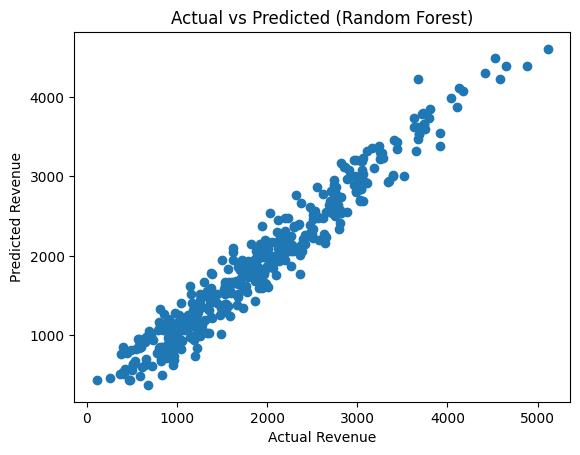

In [10]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

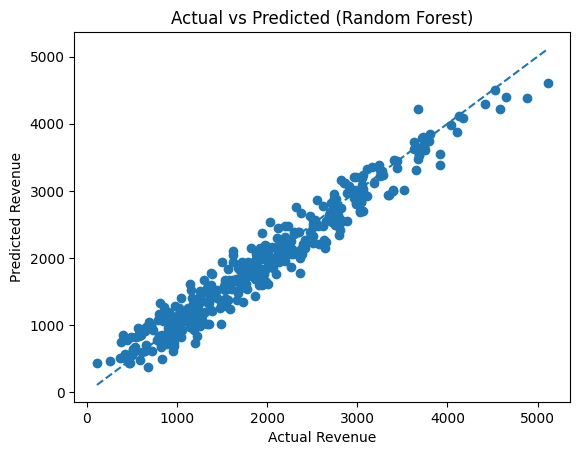

In [11]:
plt.figure()
plt.scatter(y_test, y_pred_rf)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()